'./weather_csv/weather_data1.csv' 로드 완료 (최근 데이터):
    지점 지점명         날짜  평균기온  최저기온  최고기온  강수량
0  108  서울 2020-01-01  -2.2  -6.5   0.3  0.1
1  108  서울 2020-01-02   1.0  -0.7   3.8  0.0
2  108  서울 2020-01-03  -0.1  -3.4   4.6  0.0
3  108  서울 2020-01-04   1.2  -2.8   6.1  0.0
4  108  서울 2020-01-05   1.3  -3.2   6.6  0.0

 './weather_csv/weather_past_data1.csv' 로드 완료 (과거 데이터):
    지점 지점명         날짜  평균기온  최저기온  최고기온  강수량
0  108  서울 1995-01-01  -2.8  -5.9   1.1  0.0
1  108  서울 1995-01-02  -1.1  -5.9   3.6  0.0
2  108  서울 1995-01-03   0.9  -0.4   1.6  3.7
3  108  서울 1995-01-04   0.2  -3.6   2.2  0.4
4  108  서울 1995-01-05  -2.2  -4.7   1.3  0.5

 병합된 데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   지점      3653 non-null   int64         
 1   지점명     3653 non-null   object        
 2   날짜      3653 non-null   datetime64[ns]
 3   평균기온 

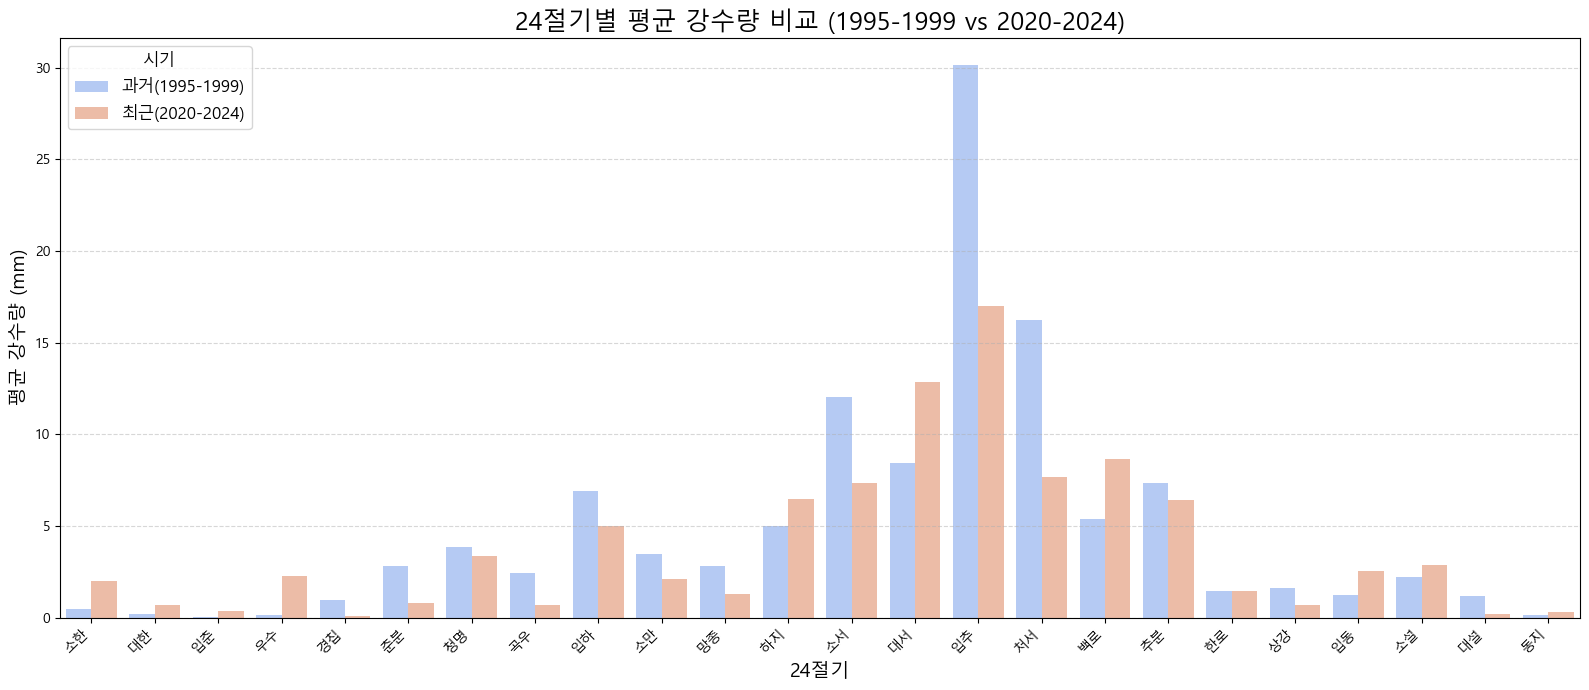

In [16]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import platform 

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'    
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False 

solar_terms = {
    "소한": "01-05", "대한": "01-20", "입춘": "02-04", "우수": "02-19",
    "경칩": "03-05", "춘분": "03-20", "청명": "04-04", "곡우": "04-20",
    "입하": "05-05", "소만": "05-21", "망종": "06-05", "하지": "06-21",
    "소서": "07-07", "대서": "07-22", "입추": "08-07", "처서": "08-23",
    "백로": "09-07", "추분": "09-23", "한로": "10-08", "상강": "10-23",
    "입동": "11-07", "소설": "11-22", "대설": "12-07", "동지": "12-22"
}

solar_term_order = list(solar_terms.keys())

rename_dict = {
    '일시': '날짜',
    '평균기온(°C)': '평균기온',
    '최저기온(°C)': '최저기온',
    '최고기온(°C)': '최고기온',
    '일강수량(mm)': '강수량' 
}

try:
    df_recent = pd.read_csv("./weather_csv/weather_data1.csv", encoding="cp949").rename(columns=rename_dict)
    df_recent['날짜'] = pd.to_datetime(df_recent['날짜'])
    df_recent['강수량'] = pd.to_numeric(df_recent['강수량'], errors='coerce').fillna(0.0)
    print(f"'./weather_csv/weather_data1.csv' 로드 완료 (최근 데이터):")
    print(df_recent.head())

    df_past = pd.read_csv("./weather_csv/weather_past_data1.csv", encoding="cp949").rename(columns=rename_dict)
    df_past['날짜'] = pd.to_datetime(df_past['날짜'])
    df_past['강수량'] = pd.to_numeric(df_past['강수량'], errors='coerce').fillna(0.0)
    print(f"\n './weather_csv/weather_past_data1.csv' 로드 완료 (과거 데이터):")
    print(df_past.head())

    df_combined = pd.concat([df_past, df_recent]).reset_index(drop=True)
    print("\n 병합된 데이터프레임 정보:")
    print(df_combined.info())

except FileNotFoundError:
    print(" 오류 : CSV 파일을 찾을 수 없습니다. ")
    exit()
except Exception as e:
    print(f" 데이터 로드 또는 전처리 중 오류 발생: {e}")
    exit() 

def extract_term_data(df_input, term_dict, window=3):
    results = []
    for term_name, month_day in term_dict.items():
        for year in df_input["날짜"].dt.year.unique():
            try:
                term_date = pd.to_datetime(f"{year}-{month_day}")

                start_date = term_date - pd.Timedelta(days=window)
                end_date = term_date + pd.Timedelta(days=window)

                mask = (df_input["날짜"] >= start_date) & (df_input["날짜"] <= end_date)
                subset = df_input[mask]

                if not subset.empty:
                    results.append({
                        "절기": term_name,
                        "연도": year,
                        "강수량": subset["강수량"].mean() 
                    })
            except ValueError:
            
                continue
    return pd.DataFrame(results)


term_data_df = extract_term_data(df_combined, solar_terms)

term_data_df["시기"] = "기타"
term_data_df.loc[(term_data_df["연도"] >= 1995) & (term_data_df["연도"] <= 1999), "시기"] = "과거(1995-1999)"
term_data_df.loc[(term_data_df["연도"] >= 2020) & (term_data_df["연도"] <= 2024), "시기"] = "최근(2020-2024)"

term_data_df = term_data_df[term_data_df["시기"] != "기타"].copy()

term_data_df["절기"] = pd.Categorical(term_data_df["절기"], categories=solar_term_order, ordered=True)

print(term_data_df.head())
print("\n--- 시기별 데이터 개수 ---")
print(term_data_df["시기"].value_counts())

# --- 시각화 ---
plt.figure(figsize=(16, 7)) 
sns.barplot(data=term_data_df, x="절기", y="강수량", hue="시기", palette="coolwarm", errorbar=None)
plt.title("24절기별 평균 강수량 비교 (1995-1999 vs 2020-2024)", fontsize=18)
plt.ylabel("평균 강수량 (mm)", fontsize=14)
plt.xlabel("24절기", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="시기", loc='upper left', fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.show()
